In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, BatchNormalization
from tensorflow.keras.layers import Bidirectional, GRU, Dense
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam, AdamW

def cnn1d_bigru_model(input_shape, num_classes):
    model = Sequential()

    # CNN Block 1
    model.add(Conv1D(64, kernel_size=5, activation='relu', padding='same',
                     kernel_regularizer=l2(1e-3), input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))

    # CNN Block 2
    model.add(Conv1D(128, kernel_size=5, activation='relu', padding='same',
                     kernel_regularizer=l2(1e-3)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.35))

    # CNN Block 3
    model.add(Conv1D(256, kernel_size=3, activation='relu', padding='same',
                     kernel_regularizer=l2(1e-3)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.35))

    # Bidirectional GRU
    model.add(Bidirectional(GRU(128, return_sequences=False, recurrent_dropout=0.2)))
    model.add(Dropout(0.4))

    # Fully Connected
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(1e-3)))
    model.add(Dropout(0.5))
    model.add(Dense(num_classes, activation='softmax'))

    # Compile
    model.compile(optimizer=AdamW(learning_rate=1e-3, weight_decay=1e-5),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    return model


# Per Frame

## Ref: Mouth

In [18]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Vector\mouth"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [19]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 35s 52ms/step - loss: 2.4744 - accuracy: 0.3353 - val_loss: 1.7118 - val_accuracy: 0.6232 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 11s 39ms/step - loss: 1.6542 - accuracy: 0.6129 - val_loss: 1.3455 - val_accuracy: 0.7339 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 12s 43ms/step - loss: 1.3316 - accuracy: 0.7308 - val_loss: 1.0930 - val_accuracy: 0.8009 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 13s 47ms/step - loss: 1.1362 - accuracy: 0.7891 - val_loss: 0.9148 - val_accuracy: 0.8455 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 17s 63ms/step - loss: 1.0291 - accuracy: 0.8158 - val_loss: 0.7979 - val_accuracy: 0.8920 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 19s 68ms/step - loss: 0.9638 - accuracy: 0.8355 - val_loss: 0.8112 - val_accuracy: 0.8777 - lr: 0.0010
Epoch 7/200
280/280 [==============================]

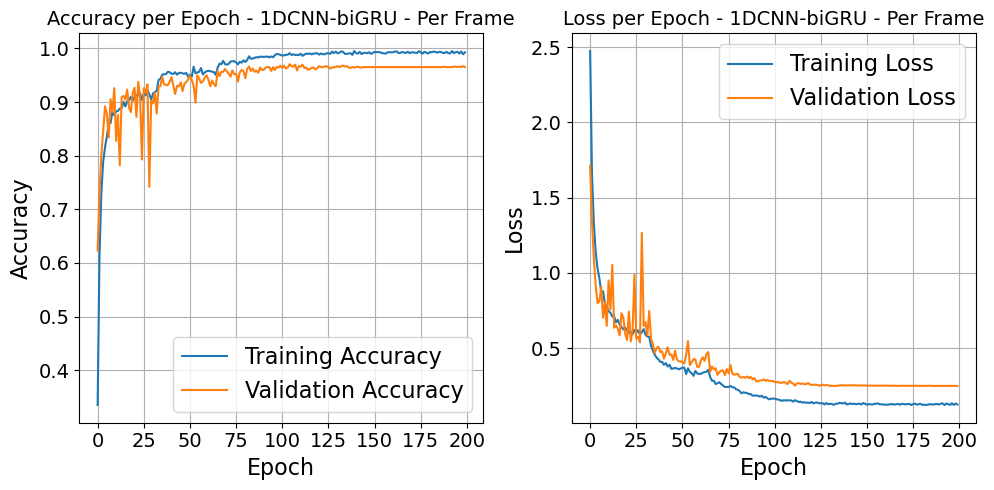

In [20]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_bigru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-biGRU"
titik_ref = 'mouth'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-vec.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'mouth'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-biGRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-biGRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-bigru_model-all-vec.png"))
plt.show()

## Ref: Nose

In [21]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Vector\nose"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [22]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 18s 27ms/step - loss: 2.4818 - accuracy: 0.3520 - val_loss: 1.7134 - val_accuracy: 0.6304 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 6s 20ms/step - loss: 1.5873 - accuracy: 0.6493 - val_loss: 1.6354 - val_accuracy: 0.6616 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 5s 20ms/step - loss: 1.2562 - accuracy: 0.7594 - val_loss: 1.1784 - val_accuracy: 0.7821 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 5s 20ms/step - loss: 1.1119 - accuracy: 0.8076 - val_loss: 0.8887 - val_accuracy: 0.8652 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 6s 20ms/step - loss: 1.0096 - accuracy: 0.8295 - val_loss: 0.7782 - val_accuracy: 0.9009 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 6s 20ms/step - loss: 0.9324 - accuracy: 0.8449 - val_loss: 0.8317 - val_accuracy: 0.8830 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s

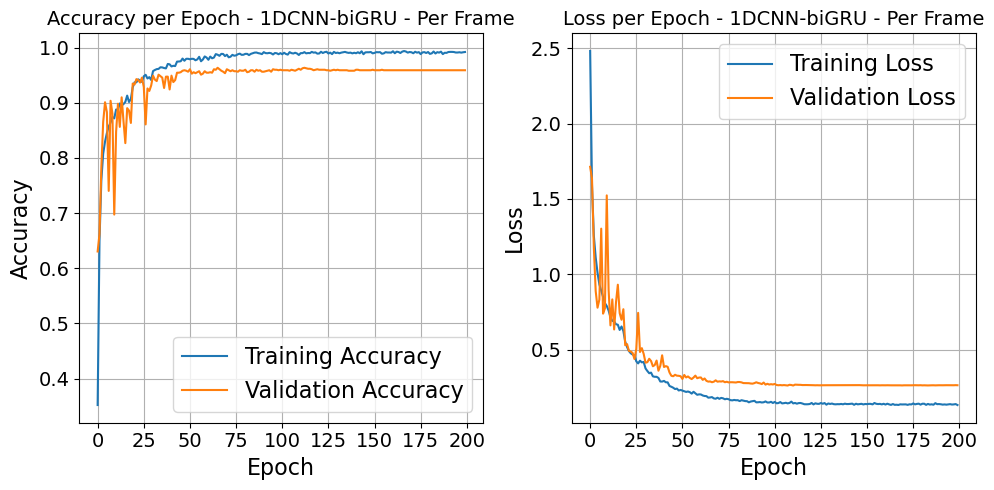

In [23]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_bigru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-biGRU"
titik_ref = 'nose'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-vec.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'nose'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-biGRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-biGRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-bigru_model-all-vec.png"))
plt.show()

## Ref: Chin

In [24]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Vector\chin"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [25]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 10s 23ms/step - loss: 2.7176 - accuracy: 0.2632 - val_loss: 4.0144 - val_accuracy: 0.1875 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 6s 20ms/step - loss: 1.8070 - accuracy: 0.5614 - val_loss: 2.1204 - val_accuracy: 0.5009 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 6s 21ms/step - loss: 1.4422 - accuracy: 0.6875 - val_loss: 1.8130 - val_accuracy: 0.5875 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 6s 20ms/step - loss: 1.2453 - accuracy: 0.7467 - val_loss: 0.9036 - val_accuracy: 0.8589 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 6s 20ms/step - loss: 1.1006 - accuracy: 0.7960 - val_loss: 0.9893 - val_accuracy: 0.8107 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 6s 21ms/step - loss: 1.0257 - accuracy: 0.8047 - val_loss: 0.8243 - val_accuracy: 0.8768 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s

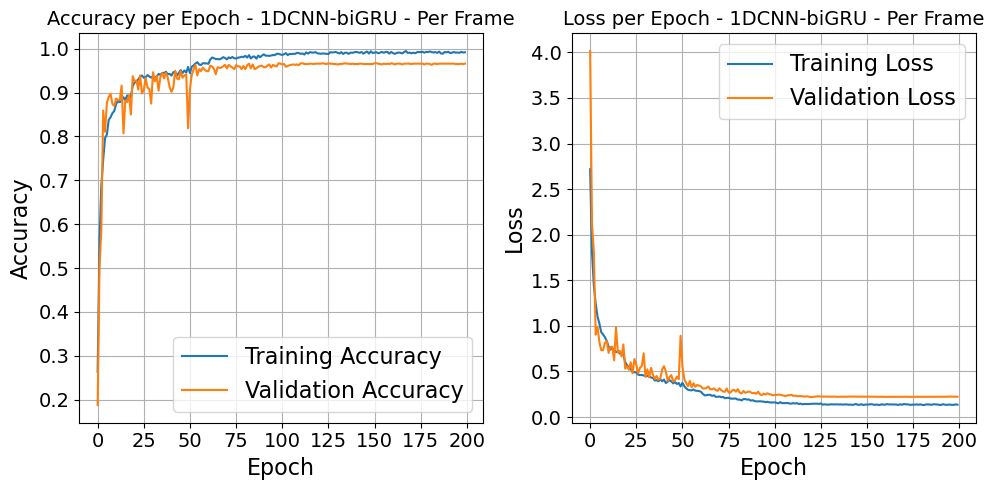

In [26]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_bigru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-biGRU"
titik_ref = 'chin'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-vec.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'chin'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-biGRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-biGRU - Per Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-bigru_model-all-vec.png"))
plt.show()

# Delta Frame

## Ref: Mouth

In [27]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Delta Vector\mouth"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [28]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 12s 25ms/step - loss: 2.9770 - accuracy: 0.1746 - val_loss: 2.2251 - val_accuracy: 0.4589 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 5s 18ms/step - loss: 2.2580 - accuracy: 0.4109 - val_loss: 1.4304 - val_accuracy: 0.7152 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 6s 20ms/step - loss: 1.6942 - accuracy: 0.5920 - val_loss: 1.1713 - val_accuracy: 0.7884 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 5s 20ms/step - loss: 1.4012 - accuracy: 0.7029 - val_loss: 0.9588 - val_accuracy: 0.8402 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 5s 19ms/step - loss: 1.2253 - accuracy: 0.7576 - val_loss: 0.9266 - val_accuracy: 0.8643 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 5s 19ms/step - loss: 1.1009 - accuracy: 0.8036 - val_loss: 0.8383 - val_accuracy: 0.8839 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s

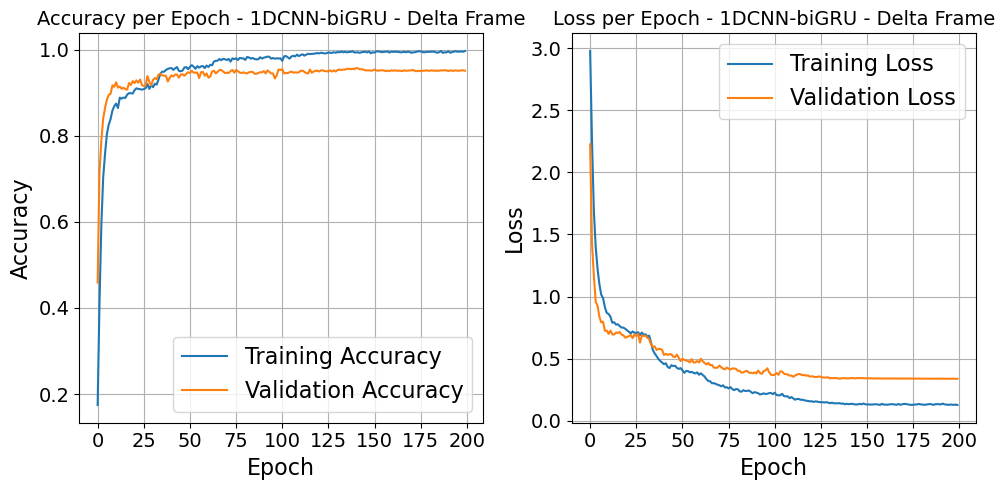

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_bigru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-biGRU"
titik_ref = 'mouth'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-del.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])


# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'mouth'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-biGRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-biGRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-bigru_model-all-del.png"))
plt.show()

## Ref: Nose

In [30]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Delta Vector\nose"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [31]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 15s 27ms/step - loss: 3.0995 - accuracy: 0.1446 - val_loss: 2.5460 - val_accuracy: 0.3357 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 6s 21ms/step - loss: 2.3839 - accuracy: 0.3748 - val_loss: 1.5064 - val_accuracy: 0.6982 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 6s 21ms/step - loss: 1.7361 - accuracy: 0.5897 - val_loss: 1.1036 - val_accuracy: 0.8054 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 6s 22ms/step - loss: 1.3958 - accuracy: 0.7174 - val_loss: 0.9619 - val_accuracy: 0.8589 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 6s 21ms/step - loss: 1.2287 - accuracy: 0.7656 - val_loss: 0.9172 - val_accuracy: 0.8598 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 6s 21ms/step - loss: 1.1042 - accuracy: 0.7991 - val_loss: 0.8437 - val_accuracy: 0.8884 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s

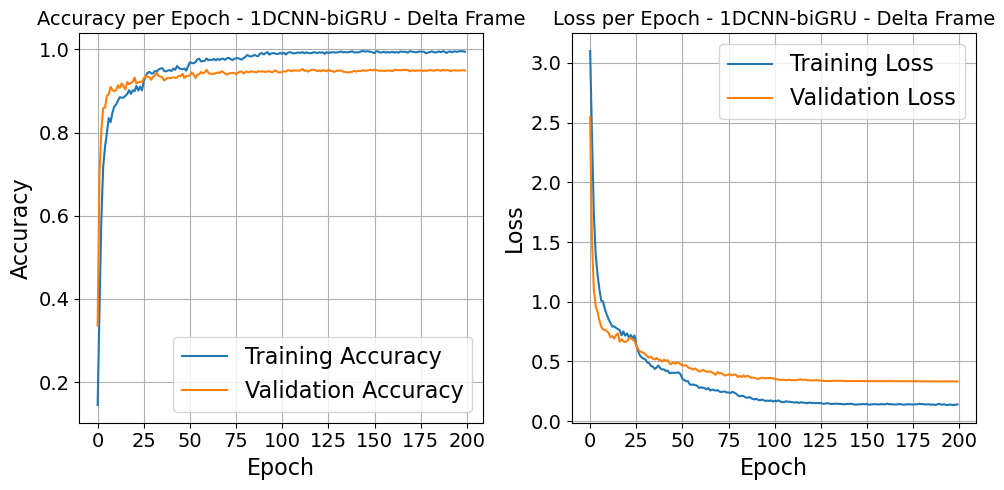

In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_bigru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-biGRU"
titik_ref = 'nose'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-del.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'nose'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-biGRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-biGRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-bigru_model-all-del.png"))
plt.show()

## Ref: Chin

In [33]:
import os
import numpy as np

# Path folder utama
base_folder = r"D:\00. Kuliah\01. S2\01. Kuliah\Thesis\01. Topic - Lipreading\Program\Thesis\Data Fitur\New\Delta Vector\chin"

# Inisialisasi list untuk data dan label
X_raw = []
Y_raw = []

target_frame_length = 44

# Iterasi setiap folder kelas
for class_name in os.listdir(base_folder):
    class_path = os.path.join(base_folder, class_name)
    
    if not os.path.isdir(class_path):
        continue  # Lewati jika bukan folder

    # Iterasi setiap file .npy di dalam folder kelas
    for filename in os.listdir(class_path):
        if filename.endswith('.npy'):
            file_path = os.path.join(class_path, filename)
            
            # Muat data .npy
            data = np.load(file_path)
            if data.shape[0] >= target_frame_length:
                # Potong ke 44 frame pertama
                data_trimmed = data[:target_frame_length]
                X_raw.append(data_trimmed)
                Y_raw.append(class_name)
                print(f"[INFO] Dimuat: {filename}-{class_name} → shape: {data_trimmed.shape}")
            else:
                print(f"[LEWATI] {filename}-{class_name} → frame {data.shape[0]} < {target_frame_length}")

# Ubah menjadi numpy array jika dimensi seragam
try:
    X_raw = np.array(X_raw)
except ValueError:
    print("Data memiliki dimensi tidak seragam, tetap dalam bentuk list.")

Y_raw = np.array(Y_raw)

# Cek hasil
print(f"Jumlah sample: {len(X_raw)}")
print(f"Label unik: {np.unique(Y_raw)}")


[INFO] Dimuat: 0415-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135609_Air_01-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135617_Air_02-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135625_Air_03-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135637_Air_04-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135645_Air_05-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135655_Air_06-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135702_Air_07-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135709_Air_08-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135716_Air_09-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135724_Air_10-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135731_Air_11-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135738_Air_12-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_135746_Air_13-Air.npy-Air → shape: (44, 40, 8)
[INFO] Dimuat: 20250508_

In [34]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler

X = X_raw.copy()
Y = Y_raw.copy()
print(X.shape)
print(Y.shape)
X = X[:,:,:, [4, 5, 6, 7]]
print(X.shape)
X_reshaped = X.reshape(X.shape[0], 44, -1)
print(f"X_reshaped: {X_reshaped.shape}")

# --- Normalisasi vx dan vy per video (per sample) ---

# ======================== (Min Max Normalisation) ===================================
#X_norm = np.zeros_like(X)
#
#for i in range(X.shape[0]):  # iterate per video
#    # Ambil vx dan vy
#    vx = X[i, :, :, 0]
#    vy = X[i, :, :, 1]
#
#    # Normalisasi ke 0-1 per video
#    vx_min, vx_max = vx.min(), vx.max()
#    vy_min, vy_max = vy.min(), vy.max()

#    vx_norm = (vx - vx_min) / (vx_max - vx_min + 1e-8)
#    vy_norm = (vy - vy_min) / (vy_max - vy_min + 1e-8)

    # Masukkan kembali ke array
#    X_norm[i, :, :, 0] = vx_norm
#    X_norm[i, :, :, 1] = vy_norm
#    X_norm[i, :, :, 2] = X[i, :, :, 2]  # angle tetap

#print("Normalized shape:", X_norm.shape)
# ====================================================================================

X_norm = np.zeros_like(X)

for i in range(X.shape[0]):  # iterate per video
    # Ambil vx dan vy, lalu reshape menjadi 2 kolom (frame * landmark, fitur)
    vx_vy = X[i, :, :, :2].reshape(-1, 2)  # gabungkan vx dan vy
    mag = X[i, :, :, 2]

    # Terapkan Standard Scaler
    scaler = StandardScaler()
    vx_vy_scaled = scaler.fit_transform(vx_vy)
    mag_scaled = scaler.fit_transform(mag)

    # Kembalikan ke bentuk semula
    vx_scaled = vx_vy_scaled[:, 0].reshape(X.shape[1], X.shape[2])
    vy_scaled = vx_vy_scaled[:, 1].reshape(X.shape[1], X.shape[2])

    # Masukkan kembali ke array
    X_norm[i, :, :, 0] = vx_scaled
    X_norm[i, :, :, 1] = vy_scaled
    X_norm[i, :, :, 2] = mag_scaled
    X_norm[i, :, :, 3] = X[i, :, :, 3]  # angle tetap tidak dinormalisasi

print("Normalized shape:", X_norm.shape)

# --- Reshape untuk model 1D CNN ---
X_reshaped = X_norm.reshape(X_norm.shape[0], X_norm.shape[1], -1)
print(f"X_reshaped: {X_reshaped.shape}")

le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
Y_binary = to_categorical(Y_encoded)

X_train, X_test, Y_train, Y_test = train_test_split(
    X_reshaped, Y_binary, test_size=0.2, random_state=42, stratify=Y_binary
)

class_weights = compute_class_weight(class_weight='balanced',
                                     classes=np.unique(Y_encoded),
                                     y=Y_encoded)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)

(5600, 44, 40, 8)
(5600,)
(5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)
Normalized shape: (5600, 44, 40, 4)
X_reshaped: (5600, 44, 160)


Epoch 1/200
280/280 [==============================] - 16s 26ms/step - loss: 3.1511 - accuracy: 0.1152 - val_loss: 2.7102 - val_accuracy: 0.2848 - lr: 0.0010
Epoch 2/200
280/280 [==============================] - 6s 22ms/step - loss: 2.5908 - accuracy: 0.2929 - val_loss: 1.8265 - val_accuracy: 0.6009 - lr: 0.0010
Epoch 3/200
280/280 [==============================] - 6s 22ms/step - loss: 2.0209 - accuracy: 0.4946 - val_loss: 1.3324 - val_accuracy: 0.7348 - lr: 0.0010
Epoch 4/200
280/280 [==============================] - 5s 19ms/step - loss: 1.6370 - accuracy: 0.6167 - val_loss: 1.1775 - val_accuracy: 0.7732 - lr: 0.0010
Epoch 5/200
280/280 [==============================] - 6s 21ms/step - loss: 1.4333 - accuracy: 0.6875 - val_loss: 1.0748 - val_accuracy: 0.7982 - lr: 0.0010
Epoch 6/200
280/280 [==============================] - 6s 21ms/step - loss: 1.3308 - accuracy: 0.7217 - val_loss: 1.0077 - val_accuracy: 0.8232 - lr: 0.0010
Epoch 7/200
280/280 [==============================] - 6s

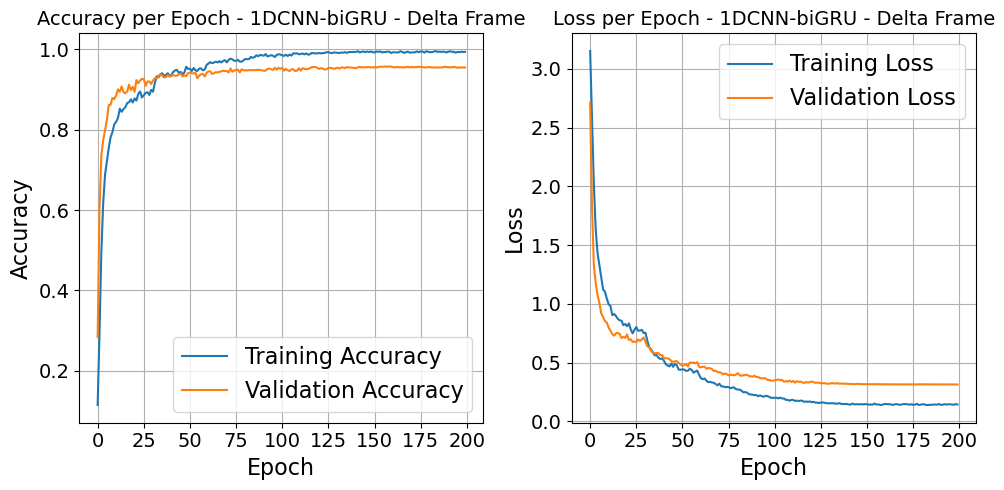

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import pandas as pd

num_classes = Y_binary.shape[1]
model = cnn1d_bigru_model(input_shape=X_reshaped.shape[1:], num_classes=num_classes)
history = model.fit(X_train, Y_train,
                    validation_data=(X_test, Y_test),
                    epochs=200,
                    batch_size=16,
                    class_weight=class_weight_dict,
                    callbacks=[reduce_lr])

tanggal = datetime.now().strftime('%Y-%m-%d-%M-%H')
model_name = "1DCNN-biGRU"
titik_ref = 'chin'
#model.save(f"Model/{tanggal}-{model_name}-{titik_ref}-all-del.h5")

# --- Evaluasi ---
loss, acc = model.evaluate(X_test, Y_test, verbose=0)
print(f"\n[HASIL UJI] Akurasi: {acc:.4f}, Loss: {loss:.4f}")

# --- Prediksi ---
Y_pred_prob = model.predict(X_test)
Y_pred = np.argmax(Y_pred_prob, axis=1)
Y_true = np.argmax(Y_test, axis=1)

# --- Confusion Matrix ---
cm = confusion_matrix(Y_true, Y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]*100

print("Confusion Matrix:")
print(confusion_matrix(Y_true, Y_pred))
print("===============================================")
print("\nClassification Report:")
print(classification_report(Y_true, Y_pred))
print("===============================================")

report = classification_report(Y_true, Y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()
df_report[['precision', 'recall', 'f1-score']] *= 100
df_report[['precision', 'recall', 'f1-score']] = df_report[['precision', 'recall', 'f1-score']].round(2)
print("\nClassification Report (dalam %):")
print(df_report[['precision', 'recall', 'f1-score', 'support']])

# --- ROC Curve ---
fpr = {}
tpr = {}
roc_auc = {}
n_classes = Y_test.shape[1]
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], Y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Konfigurasi penyimpanan gambar ---
titik_ref = 'chin'  # Ganti jika perlu
tanggal = datetime.now().strftime('%Y-%m-%d')
folder_name = f"{tanggal}-{titik_ref}-revisi"
save_dir = os.path.join("Result", folder_name)
os.makedirs(save_dir, exist_ok=True)

plt.figure(figsize=(10, 5))

# Plot Akurasi
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy per Epoch - 1DCNN-biGRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Accuracy', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss per Epoch - 1DCNN-biGRU - Delta Frame', fontsize=14) # Ukuran font judul
plt.xlabel('Epoch', fontsize=16) # Ukuran font label x
plt.ylabel('Loss', fontsize=16) # Ukuran font label y
plt.legend(fontsize=16) # Ukuran font legenda
plt.xticks(fontsize=14) # Ukuran font tick x (angka pada sumbu)
plt.yticks(fontsize=14) # Ukuran font tick y (angka pada sumbu)
plt.grid(True)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, f"{tanggal}-acc_loss-cnn1d-bigru_model-all-del.png"))
plt.show()